In [12]:
# =========================================================
# STEP 1: INITIALIZE ENVIRONMENT & IMPORTS
# =========================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from datetime import timedelta
import pickle

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import confusion_matrix, roc_curve, auc

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sentence_transformers import SentenceTransformer

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Define local paths
base_path = "./dataset/"
models_path = "./models/"
results_path = "./results/evaluation_results/"
plots_path = "./results/evaluation_plots/"

for path in [base_path, models_path, results_path, plots_path]:
    os.makedirs(path, exist_ok=True)

# Hyperparameters
NCF_EMBEDDING_DIM = 64
NCF_EPOCHS = 20
NCF_BATCH_SIZE = 128
NCF_LR = 0.001
NCF_NEGATIVE_SAMPLES = 4
KNN_K = 30
SVD_N_FACTORS = 100
SVD_REG = 0.02
HYBRID_RECENT_ITEMS = 5
TOP_K = 5

# Decay Parameters
DECAY_ALPHA_MIN = 0.3
DECAY_ALPHA_RANGE = 0.4
DECAY_LAMBDA = 0.1

print("✅ Local environment initialized successfully.")

✅ Local environment initialized successfully.


In [13]:
# =========================================================
# STEP 2: LOAD & PREPROCESS DATASETS
# =========================================================
dataset_file = os.path.join(base_path, "ecommarce_full_dataset.csv")
print(f"📂 Loading Dataset from: {dataset_file}")

df = pd.read_csv(dataset_file)

# 1. Handle Nulls
df['product_name'] = df['product_name'].fillna('')
df['brand'] = df['brand'].fillna('')
if 'rating' not in df.columns:
    df['rating'] = 3.0
else:
    df['rating'] = df['rating'].fillna(3.0)

# 2. Assign Categories (Inference)
def _assign_cat(row):
    text = (str(row['product_name']) + " " + str(row.get('search_query', ''))).lower()
    if any(word in text for word in ['phone', 'iphone', 'samsung galaxy', 'smartphone']): return 'Smartphones'
    elif any(word in text for word in ['kindle', 'e-reader', 'eink']): return 'E-Readers'
    elif any(word in text for word in ['mouse', 'keyboard', 'monitor', 'mac mini', 'dock']): return 'Computer Accessories'
    elif any(word in text for word in ['headphone', 'earbud', 'audio', 'noise canceling']): return 'Audio & Headphones'
    elif any(word in text for word in ['tv', 'remote', 'ethernet', 'stick']): return 'Electronics Accessories'
    elif any(word in text for word in ['case', 'cover', 'skin', 'screen protector']): return 'Tech Accessories'
    elif any(word in text for word in ['battery', 'ssd', 'ram', 'cpu']): return 'Computer Parts'
    elif any(word in text for word in ['playstation', 'ps5', 'xbox', 'nintendo', 'game']): return 'Gaming'
    return 'General Electronics'

if df['category'].isnull().mean() > 0.5:
    df['category'] = df.apply(_assign_cat, axis=1)
else:
    df['category'] = df['category'].fillna('')

# 3. Assign Brands
def _assign_brand(row):
    current_brand = str(row['brand'])
    if current_brand and current_brand != 'nan' and current_brand != 'Mock_brand':
        return current_brand
    text = str(row['product_name']).lower()
    known_brands = ['apple', 'samsung', 'sony', 'logitech', 'msi', 'dell', 'amazon', 'philips', 'meebook', 'uucovers']
    for b in known_brands:
        if b in text:
            return b.capitalize()
    return 'Generic'

df['brand'] = df.apply(_assign_brand, axis=1)

# 4. Standardize text
df['combined_text'] = df['product_name'] + " " + df['category'] + " " + df['brand']

# 5. Timestamps
df['timestamp'] = pd.to_datetime(df['timestamp'])
if df['timestamp'].dt.tz is not None:
    df['timestamp'] = df['timestamp'].dt.tz_convert('UTC').dt.tz_localize(None)

# 6. Label Encoding for Deep Learning
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()
df['user_encoded'] = user_encoder.fit_transform(df['userId'])
df['item_encoded'] = item_encoder.fit_transform(df['productId'])

num_users = len(user_encoder.classes_)
num_items = len(item_encoder.classes_)

# 7. Train/Test Split (Temporal)
df = df.sort_values(by='timestamp')
split_date = pd.to_datetime('2025-12-01')
train_df = df[df['timestamp'] < split_date].copy()
test_df = df[df['timestamp'] >= split_date].copy()

all_products_df = df[['productId', 'product_name', 'category', 'brand', 'combined_text']].drop_duplicates(subset=['productId']).reset_index(drop=True)
all_products_list = all_products_df['productId'].tolist()
product_idx_map = {pid: i for i, pid in enumerate(all_products_df['productId'])}

print(f"✅ Successfully processed {len(df)} total records.")
print(f"   Train Set: {len(train_df)} | Test Set: {len(test_df)}")
print(f"   Unique Users: {num_users} | Unique Items: {num_items}")

📂 Loading Dataset from: ./dataset/ecommarce_full_dataset.csv
✅ Successfully processed 4984 total records.
   Train Set: 3932 | Test Set: 1052
   Unique Users: 50 | Unique Items: 3006


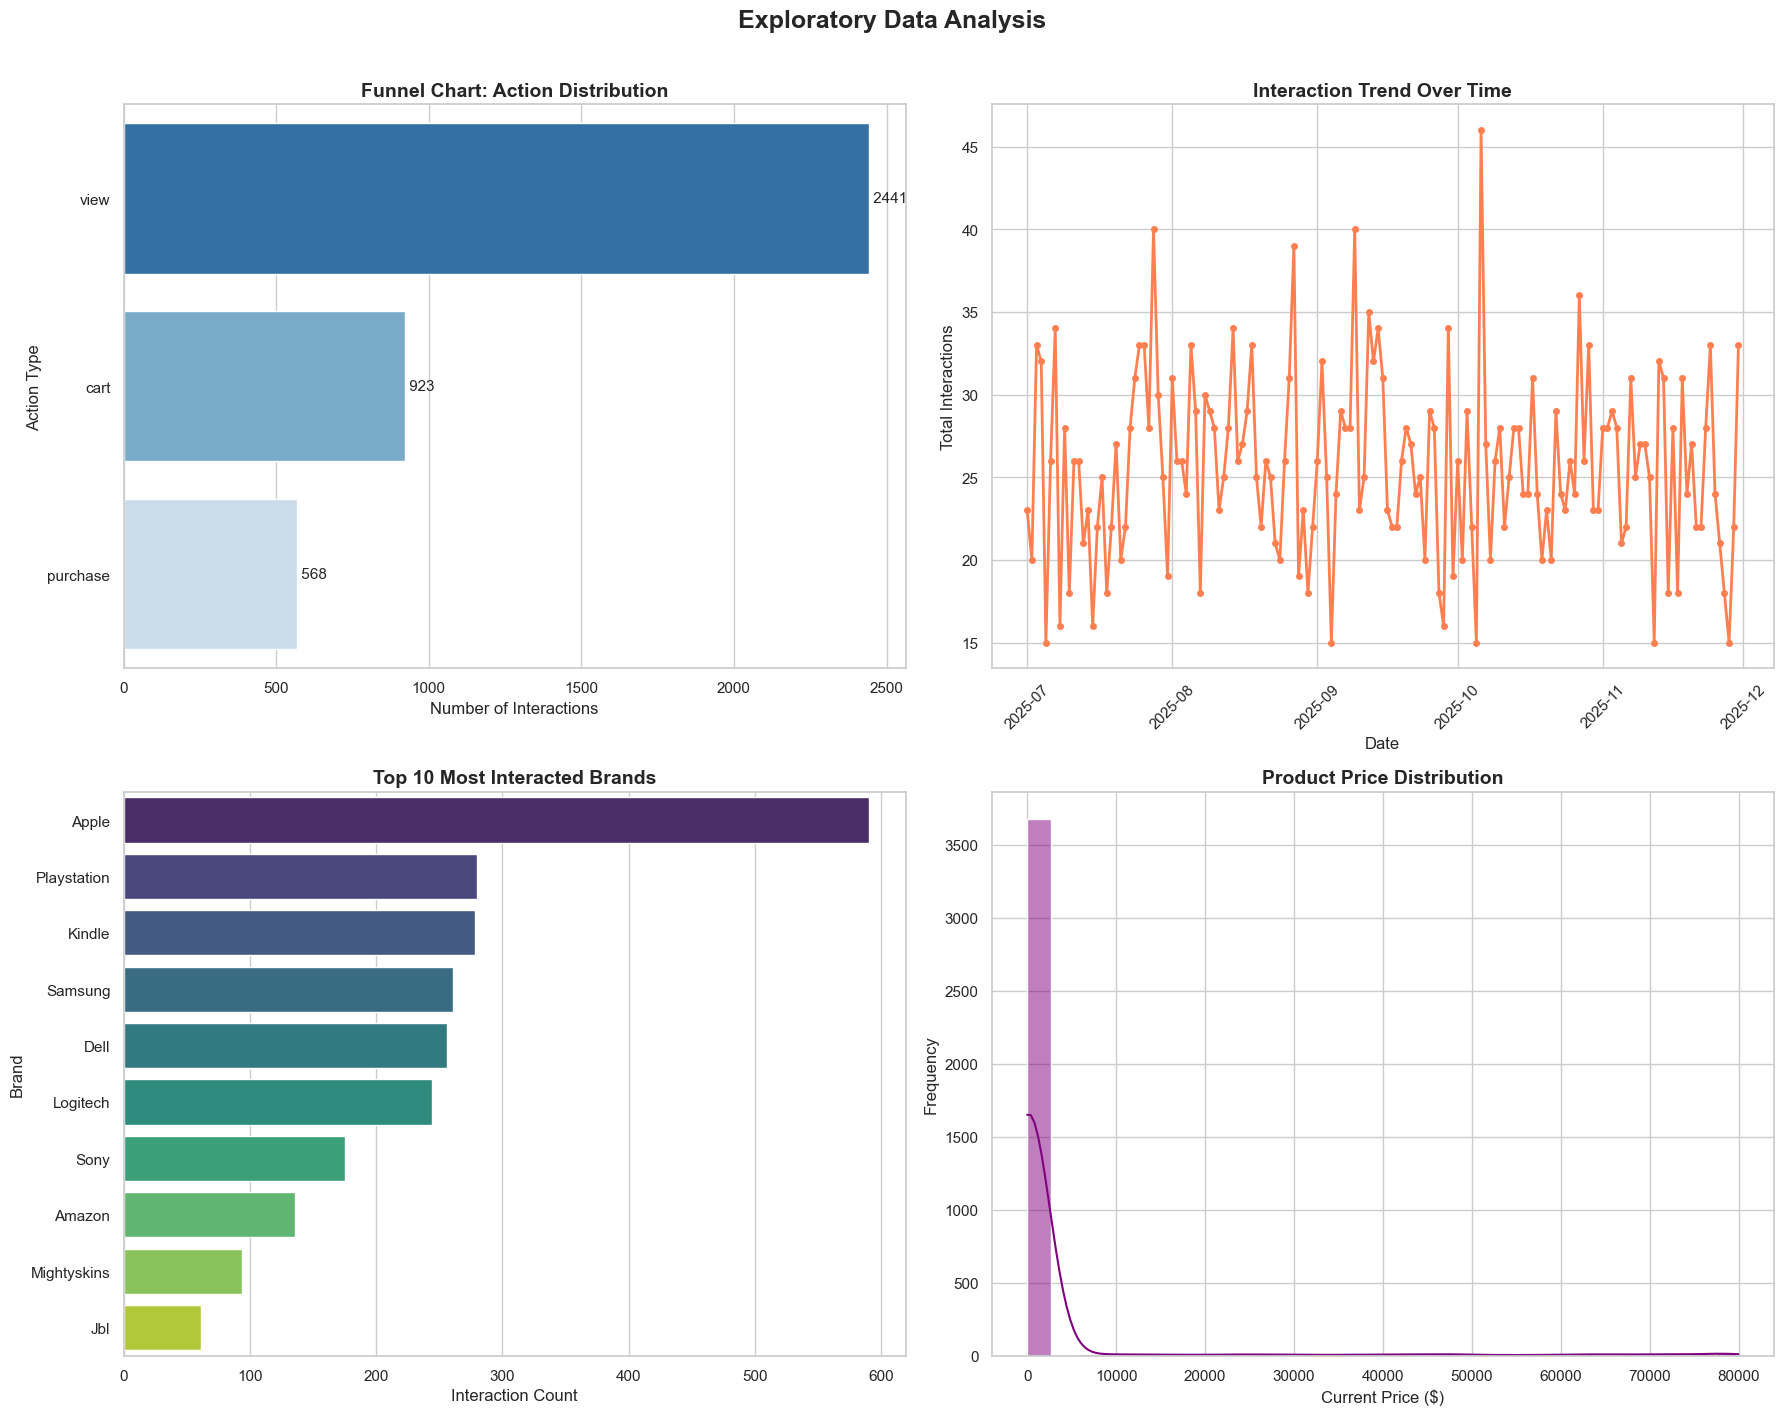

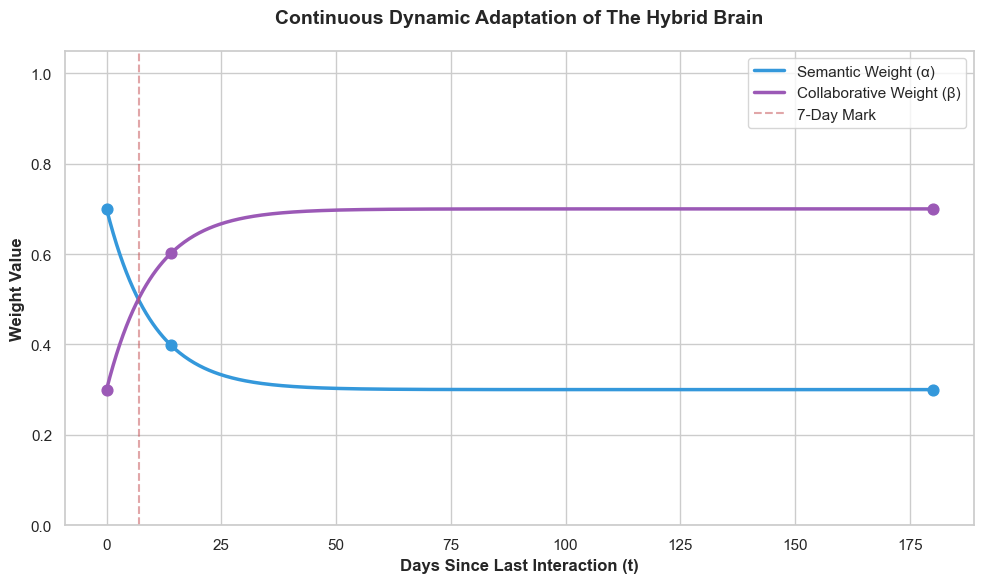

✅ EDA complete.


In [14]:
# =========================================================
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Action Funnel
ax1 = axes[0, 0]
action_counts = train_df['action_type'].value_counts().reindex(['view', 'cart', 'purchase'])
sns.barplot(y=action_counts.index, x=action_counts.values, palette="Blues_r", ax=ax1)
ax1.set_title('Funnel Chart: Action Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Interactions')
ax1.set_ylabel('Action Type')
for index, value in enumerate(action_counts.values):
    if not np.isnan(value):
        ax1.text(value, index, f' {int(value)}', va='center', fontsize=11)

# Plot 2: Interaction Trend
ax2 = axes[0, 1]
daily_interactions = train_df.groupby(train_df['timestamp'].dt.date).size()
ax2.plot(daily_interactions.index, daily_interactions.values, marker="o", color="coral", linewidth=2, markersize=4)
ax2.set_title('Interaction Trend Over Time', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Total Interactions')
ax2.tick_params(axis='x', rotation=45)

# Plot 3: Top Brands
ax3 = axes[1, 0]
top_brands = train_df['brand'].value_counts().head(10)
sns.barplot(x=top_brands.values, y=top_brands.index, palette="viridis", ax=ax3)
ax3.set_title('Top 10 Most Interacted Brands', fontsize=14, fontweight='bold')
ax3.set_xlabel('Interaction Count')
ax3.set_ylabel('Brand')

# Plot 4: Price Distribution
ax4 = axes[1, 1]
sns.histplot(train_df['current_price'].dropna(), bins=30, kde=True, color="purple", ax=ax4)
ax4.set_title('Product Price Distribution', fontsize=14, fontweight='bold')
ax4.set_xlabel('Current Price ($)')
ax4.set_ylabel('Frequency')

plt.suptitle('Exploratory Data Analysis', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(plots_path, 'eda_overview.png'), dpi=300, bbox_inches='tight')
plt.show()

# Dynamic Weights Curve
plt.figure(figsize=(10, 6))
t_days = np.linspace(0, 180, 500)
alpha_curve = DECAY_ALPHA_MIN + DECAY_ALPHA_RANGE * np.exp(-DECAY_LAMBDA * t_days)
beta_curve = 1.0 - alpha_curve

plt.plot(t_days, alpha_curve, label='Semantic Weight (α)', color='#3498db', linewidth=2.5)
plt.plot(t_days, beta_curve, label='Collaborative Weight (β)', color='#9b59b6', linewidth=2.5)
plt.title('Continuous Dynamic Adaptation of The Hybrid Brain', pad=20, fontweight='bold', fontsize=14)
plt.xlabel('Days Since Last Interaction (t)', fontweight='bold')
plt.ylabel('Weight Value', fontweight='bold')
plt.axvline(x=7, color='r', linestyle='--', alpha=0.5, label='7-Day Mark')

points = [0, 14, 180]
for p in points:
    a_val = DECAY_ALPHA_MIN + DECAY_ALPHA_RANGE * np.exp(-DECAY_LAMBDA * p)
    plt.scatter(p, a_val, color='#3498db', s=60, zorder=5)
    plt.scatter(p, 1-a_val, color='#9b59b6', s=60, zorder=5)

plt.legend()
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig(os.path.join(plots_path, 'dynamic_weights_curve.png'), dpi=300)
plt.show()
print("✅ EDA complete.")

In [15]:
# =========================================================
# STEP 4: UNIVERSAL EVALUATION METRICS ENGINE (Enhanced)
# =========================================================
# Now includes: Precision@K, Recall@K, F1@K, NDCG@K, MAP@K, Hit_Rate@K,
# Category Hit Rate, MRR, plus data collection for Confusion Matrix & ROC

def evaluate_model(model_name, recommend_func, top_k=TOP_K):
    print(f"\n📊 Evaluating {model_name}...")
    test_users = test_df['userId'].unique()
    
    total_precision = total_recall = total_ndcg = 0
    total_exact = total_cat = total_mrr = 0
    total_f1 = total_ap = total_hit = 0
    valid_users = 0
    
    # Data for confusion matrix and ROC
    all_pred_categories = []
    all_actual_categories = []
    all_relevance_scores = []
    all_relevance_labels = []
    
    import sys
    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')
    
    try:
        for user in test_users:
            actual_items_data = test_df[test_df['userId'] == user]
            actual_items = actual_items_data['productId'].tolist()
            actual_categories = actual_items_data['category'].dropna().unique().tolist()
            
            if not actual_items: continue
            valid_users += 1
            
            try:
                pred_recs = recommend_func(user)
                if pred_recs is None or pred_recs.empty:
                    continue
                pred_items = pred_recs['productId'].tolist()
                pred_categories = pred_recs['category'].dropna().tolist()
            except:
                continue
            
            # Collect category data for confusion matrix
            for cat in pred_categories:
                all_pred_categories.append(cat)
                if cat in actual_categories:
                    all_actual_categories.append(cat)
                else:
                    all_actual_categories.append(actual_categories[0] if actual_categories else 'Unknown')
            
            # Collect relevance data for ROC
            for item in pred_items:
                is_relevant = 1 if item in actual_items else 0
                all_relevance_labels.append(is_relevant)
                rank = pred_items.index(item) + 1
                all_relevance_scores.append(1.0 / rank)
            
            hits = len(set(pred_items) & set(actual_items))
            
            # Precision@K
            prec_k = hits / top_k
            total_precision += prec_k
            total_exact += prec_k
            
            # Recall@K
            rec_k = hits / len(actual_items)
            total_recall += rec_k
            
            # F1@K
            if prec_k + rec_k > 0:
                total_f1 += 2 * (prec_k * rec_k) / (prec_k + rec_k)
            
            # Hit Rate@K
            total_hit += 1 if hits > 0 else 0
            
            # Category Hit Rate
            cat_hits = sum(1 for cat in pred_categories if cat in actual_categories)
            total_cat += cat_hits / top_k
            
            # MRR
            for rank, item in enumerate(pred_items, 1):
                if item in actual_items:
                    total_mrr += 1.0 / rank
                    break
            
            # Average Precision (for MAP)
            ap = 0
            num_hits = 0
            for rank, item in enumerate(pred_items, 1):
                if item in actual_items:
                    num_hits += 1
                    ap += num_hits / rank
            if min(len(actual_items), top_k) > 0:
                ap /= min(len(actual_items), top_k)
            total_ap += ap
            
            # NDCG
            dcg = 0
            idcg = sum([1.0 / np.log2(i + 1) for i in range(1, min(len(actual_items), top_k) + 1)])
            for rank, item in enumerate(pred_items, 1):
                if item in actual_items:
                    dcg += 1.0 / np.log2(rank + 1)
            total_ndcg += dcg / idcg if idcg > 0 else 0
    finally:
        sys.stdout.close()
        sys.stdout = old_stdout

    n = valid_users if valid_users > 0 else 1
    results = {
        'Model': model_name,
        'Precision@K': round(total_precision / n, 4),
        'Recall@K': round(total_recall / n, 4),
        'F1@K': round(total_f1 / n, 4),
        'NDCG@K': round(total_ndcg / n, 4),
        'MAP@K': round(total_ap / n, 4),
        'Hit_Rate@K': round(total_hit / n, 4),
        'Exact_Match_Precision': round(total_exact / n, 4),
        'Category_Hit_Rate': round(total_cat / n, 4),
        'MRR': round(total_mrr / n, 4),
        '_pred_categories': all_pred_categories,
        '_actual_categories': all_actual_categories,
        '_relevance_scores': all_relevance_scores,
        '_relevance_labels': all_relevance_labels,
    }
    
    print(f"   ➤ Precision@{top_k}:  {results['Precision@K']:.4f}")
    print(f"   ➤ Recall@{top_k}:     {results['Recall@K']:.4f}")
    print(f"   ➤ F1@{top_k}:         {results['F1@K']:.4f}")
    print(f"   ➤ NDCG@{top_k}:       {results['NDCG@K']:.4f}")
    print(f"   ➤ MAP@{top_k}:        {results['MAP@K']:.4f}")
    print(f"   ➤ Hit Rate@{top_k}:   {results['Hit_Rate@K']:.4f}")
    print(f"   ➤ Category Hit Rate:  {results['Category_Hit_Rate']:.4f}")
    print(f"   ➤ MRR:               {results['MRR']:.4f}")
    return results

def normalize_scores(scores):
    if len(scores) == 0: return []
    min_val, max_val = min(scores), max(scores)
    if max_val == min_val: return [0.5 for _ in scores]
    return [(x - min_val) / (max_val - min_val) for x in scores]

In [16]:
# =========================================================
# STEP 5: BASELINE MODEL (TF-IDF + Scikit-Learn KNN)
# =========================================================
print("⚙️ Building TF-IDF (Content-Based) Model...")
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(all_products_df['combined_text'])

print("⚙️ Building KNN (Collaborative Filtering) via Scikit-Learn...")
# Create User-Item matrix for scikit-learn KNN
user_item_matrix = train_df.pivot_table(index='userId', columns='productId', values='rating', fill_value=0)
user_item_matrix = user_item_matrix.reindex(columns=all_products_list, fill_value=0)

knn = NearestNeighbors(n_neighbors=KNN_K, metric='cosine', algorithm='brute')
knn.fit(user_item_matrix.values)

def get_baseline_recommendations(target_user, top_k=TOP_K):
    # TF-IDF Score
    user_history = train_df[train_df['userId'] == target_user]['productId'].tolist()
    user_tfidf_profile = None
    if user_history:
        valid_indices = [product_idx_map[pid] for pid in user_history if pid in product_idx_map]
        if valid_indices:
            user_tfidf_profile = tfidf_matrix[valid_indices].mean(axis=0)

    tfidf_scores_raw = []
    for pid in all_products_list:
        if user_tfidf_profile is not None and pid in product_idx_map:
            p_idx = product_idx_map[pid]
            sim = cosine_similarity(np.asarray(user_tfidf_profile), tfidf_matrix[p_idx])[0][0]
            tfidf_scores_raw.append(sim)
        else:
            tfidf_scores_raw.append(0.0)

    # KNN Score
    knn_scores_raw = np.zeros(len(all_products_list))
    if target_user in user_item_matrix.index:
        user_idx = user_item_matrix.index.get_loc(target_user)
        user_vector = user_item_matrix.values[user_idx].reshape(1, -1)
        distances, indices = knn.kneighbors(user_vector, n_neighbors=min(KNN_K, len(user_item_matrix)))
        neighbor_ratings = user_item_matrix.values[indices[0]]
        avg_ratings = neighbor_ratings.mean(axis=0)
        knn_scores_raw = avg_ratings

    tfidf_norm = normalize_scores(tfidf_scores_raw)
    knn_norm = normalize_scores(knn_scores_raw)

    results = []
    for i, pid in enumerate(all_products_list):
        final_score = (0.5 * tfidf_norm[i]) + (0.5 * knn_norm[i])
        results.append({'productId': pid, 'Final_Score': final_score})

    results_df = pd.DataFrame(results).sort_values(by='Final_Score', ascending=False)
    
    # Filter purchased items
    purchased = train_df[(train_df['userId'] == target_user) & (train_df['action_type'] == 'purchase')]['productId'].tolist()
    results_df = results_df[~results_df['productId'].isin(purchased)]
    
    return pd.merge(results_df.head(top_k), all_products_df[['productId', 'product_name', 'category']], on='productId', how='left')

print("🏃 Evaluating Baseline Model...")
base_metrics = evaluate_model("Baseline (TF-IDF + KNN)", get_baseline_recommendations, top_k=TOP_K)
print("✅ Baseline Model evaluation complete.")

⚙️ Building TF-IDF (Content-Based) Model...
⚙️ Building KNN (Collaborative Filtering) via Scikit-Learn...
🏃 Evaluating Baseline Model...

📊 Evaluating Baseline (TF-IDF + KNN)...
   ➤ Precision@5:  0.0229
   ➤ Recall@5:     0.0031
   ➤ F1@5:         0.0054
   ➤ NDCG@5:       0.0245
   ➤ MAP@5:        0.0114
   ➤ Hit Rate@5:   0.1143
   ➤ Category Hit Rate:  0.9543
   ➤ MRR:               0.0571
✅ Baseline Model evaluation complete.


In [17]:
# =========================================================
# STEP 6: DEEP LEARNING (NCF TWO-TOWER) — Enhanced
# =========================================================
print("🏗️ Building Enhanced NCF Architecture...")
tf.random.set_seed(42)

# --- Negative Sampling ---
def generate_negative_samples(X_user, X_item, y, num_items, n_neg=NCF_NEGATIVE_SAMPLES):
    print(f"Generating {n_neg} negative samples per positive interaction...")
    positive_pairs = set(zip(X_user.tolist(), X_item.tolist()))
    neg_users, neg_items, neg_labels = [], [], []
    
    for u, i in zip(X_user, X_item):
        count = 0
        while count < n_neg:
            neg_item = np.random.randint(0, num_items)
            if (int(u), neg_item) not in positive_pairs:
                neg_users.append(int(u))
                neg_items.append(neg_item)
                neg_labels.append(0.0)
                count += 1
    
    all_users = np.concatenate([X_user, np.array(neg_users)])
    all_items = np.concatenate([X_item, np.array(neg_items)])
    all_labels = np.concatenate([y, np.array(neg_labels)])
    
    indices = np.random.permutation(len(all_users))
    return all_users[indices], all_items[indices], all_labels[indices]

# --- Build Model ---
user_input = Input(shape=(1,), name="User_Input")
user_embedding = Embedding(input_dim=num_users, output_dim=NCF_EMBEDDING_DIM)(user_input)
user_flat = Flatten()(user_embedding)

item_input = Input(shape=(1,), name="Item_Input")
item_embedding = Embedding(input_dim=num_items, output_dim=NCF_EMBEDDING_DIM)(item_input)
item_flat = Flatten()(item_embedding)

concat = Concatenate()([user_flat, item_flat])

dense_1 = Dense(128, activation='relu')(concat)
bn_1 = BatchNormalization()(dense_1)
drop_1 = Dropout(0.3)(bn_1)

dense_2 = Dense(64, activation='relu')(drop_1)
bn_2 = BatchNormalization()(dense_2)
drop_2 = Dropout(0.2)(bn_2)

dense_3 = Dense(32, activation='relu')(drop_2)
dense_4 = Dense(16, activation='relu')(dense_3)

output = Dense(1, activation='linear')(dense_4)

ncf_model = Model(inputs=[user_input, item_input], outputs=output)
ncf_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=NCF_LR),
    loss='mse',
    metrics=['mae']
)

ncf_model.summary()

# --- Prepare Training Data with Negative Sampling ---
X_user_train = train_df['user_encoded'].values
X_item_train = train_df['item_encoded'].values
y_train = train_df['rating'].values

X_user_aug, X_item_aug, y_aug = generate_negative_samples(X_user_train, X_item_train, y_train, num_items)
print(f"Training samples after negative sampling: {len(y_aug)} (was {len(y_train)})")

# --- Train with Callbacks ---
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print("🚀 Training Enhanced NCF Model...")
ncf_history = ncf_model.fit(
    [X_user_aug, X_item_aug], y_aug,
    batch_size=NCF_BATCH_SIZE, epochs=NCF_EPOCHS, verbose=1,
    validation_split=0.15,
    callbacks=callbacks
)
print("✅ NCF Training complete.")

🏗️ Building Enhanced NCF Architecture...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ User_Input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Item_Input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1, 64)     │      3,200 │ User_Input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 64)     │    192,384 │ Item_Input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 64)        │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 64)        │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128)       │          0 │ flatten_2[0][0],  │
│ (Concatenate)       │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     16,512 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 16)        │        528 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         17 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 223,745 (874.00 KB)

 Trainable params: 223,361 (872.50 KB)

 Non-trainable params: 384 (1.50 KB)

Generating 4 negative samples per positive interaction...
Training samples after negative sampling: 19660 (was 3932)
🚀 Training Enhanced NCF Model...
Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 3.1384 - mae: 1.2939 - val_loss: 3.0952 - val_mae: 1.2359 - learning_rate: 0.0010
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.8414 - mae: 1.2884 - val_loss: 3.0390 - val_mae: 1.3341 - learning_rate: 0.0010
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.6969 - mae: 1.2580 - val_loss: 3.1045 - val_mae: 1.2470 - learning_rate: 0.0010
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.4816 - mae: 1.1885 - val_loss: 3.2518 - val_mae: 1.1617 - learning_rate: 0.0010
Epoch 5/20
121/131 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2469 - mae: 1.1166
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.2073 - mae: 1.0910 - val_loss: 3.3874 - val_mae: 1.1471 - learning_rate: 0

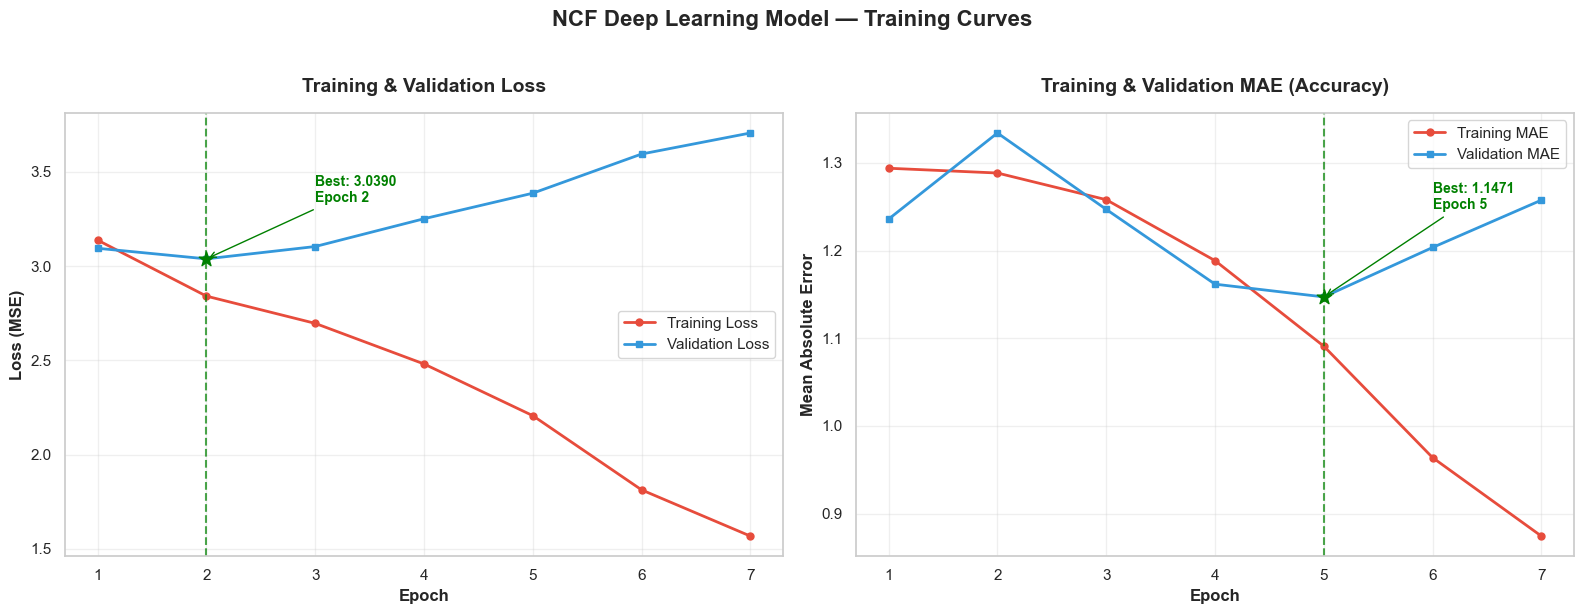

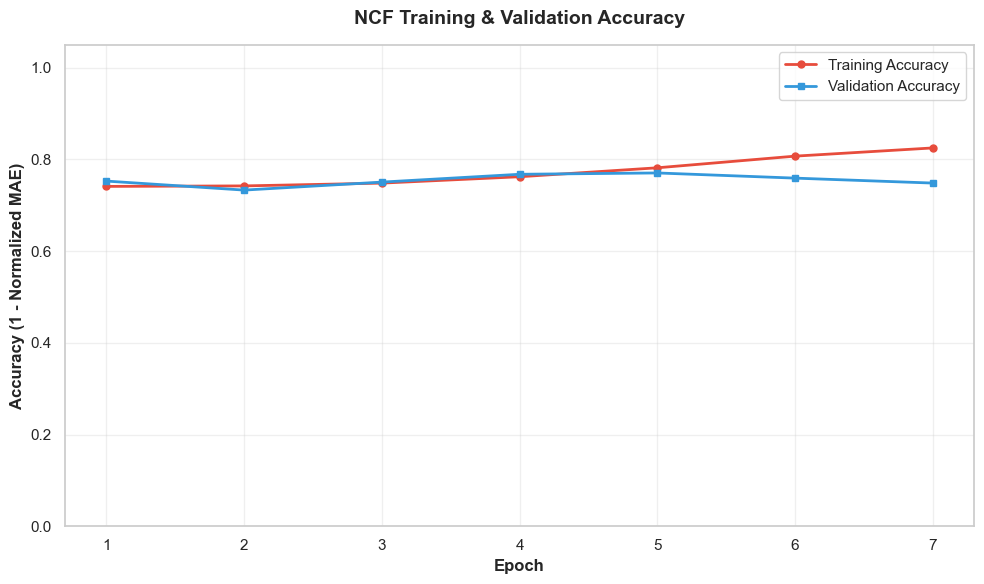

✅ Training curves generated.


In [18]:
# =========================================================
# STEP 7: NCF TRAINING & VALIDATION CURVES
# =========================================================
hist = ncf_history.history
epochs_range = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Training & Validation Loss ----
ax1 = axes[0]
ax1.plot(epochs_range, hist['loss'], 'o-', color='#e74c3c', linewidth=2, markersize=5, label='Training Loss')
if 'val_loss' in hist:
    ax1.plot(epochs_range, hist['val_loss'], 's-', color='#3498db', linewidth=2, markersize=5, label='Validation Loss')
    best_epoch_loss = np.argmin(hist['val_loss']) + 1
    best_val_loss = min(hist['val_loss'])
    ax1.axvline(x=best_epoch_loss, color='green', linestyle='--', alpha=0.7)
    ax1.scatter([best_epoch_loss], [best_val_loss], color='green', s=120, zorder=5, marker='*')
    ax1.annotate(f'Best: {best_val_loss:.4f}\nEpoch {best_epoch_loss}', 
                 xy=(best_epoch_loss, best_val_loss),
                 xytext=(best_epoch_loss + 1, best_val_loss + 0.3),
                 fontsize=10, fontweight='bold', color='green',
                 arrowprops=dict(arrowstyle='->', color='green'))

ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss (MSE)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# ---- Training & Validation MAE (Accuracy Proxy) ----
ax2 = axes[1]
if 'mae' in hist:
    ax2.plot(epochs_range, hist['mae'], 'o-', color='#e74c3c', linewidth=2, markersize=5, label='Training MAE')
    if 'val_mae' in hist:
        ax2.plot(epochs_range, hist['val_mae'], 's-', color='#3498db', linewidth=2, markersize=5, label='Validation MAE')
        best_epoch_mae = np.argmin(hist['val_mae']) + 1
        best_val_mae = min(hist['val_mae'])
        ax2.axvline(x=best_epoch_mae, color='green', linestyle='--', alpha=0.7)
        ax2.scatter([best_epoch_mae], [best_val_mae], color='green', s=120, zorder=5, marker='*')
        ax2.annotate(f'Best: {best_val_mae:.4f}\nEpoch {best_epoch_mae}',
                     xy=(best_epoch_mae, best_val_mae),
                     xytext=(best_epoch_mae + 1, best_val_mae + 0.1),
                     fontsize=10, fontweight='bold', color='green',
                     arrowprops=dict(arrowstyle='->', color='green'))

    ax2.set_title('Training & Validation MAE (Accuracy)', fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Mean Absolute Error', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

plt.suptitle('NCF Deep Learning Model — Training Curves', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(plots_path, 'ncf_training_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

# ---- Separate: Training Accuracy (1 - normalized MAE) ----
if 'mae' in hist:
    fig2, ax3 = plt.subplots(figsize=(10, 6))
    
    max_target = max(y_aug) if max(y_aug) > 0 else 5.0
    train_acc = [1 - (m / max_target) for m in hist['mae']]
    ax3.plot(epochs_range, train_acc, 'o-', color='#e74c3c', linewidth=2, markersize=5, label='Training Accuracy')
    
    if 'val_mae' in hist:
        val_acc = [1 - (m / max_target) for m in hist['val_mae']]
        ax3.plot(epochs_range, val_acc, 's-', color='#3498db', linewidth=2, markersize=5, label='Validation Accuracy')
    
    ax3.set_title('NCF Training & Validation Accuracy', fontsize=14, fontweight='bold', pad=15)
    ax3.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Accuracy (1 - Normalized MAE)', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=11)
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(0, 1.05)
    
    plt.tight_layout()
    plt.savefig(os.path.join(plots_path, 'ncf_accuracy_curves.png'), dpi=300, bbox_inches='tight')
    plt.show()

print("✅ Training curves generated.")

In [19]:
# =========================================================
# STEP 8: NCF MODEL EVALUATION
# =========================================================
def get_ncf_recommendations(target_user, top_k=TOP_K):
    if target_user not in user_encoder.classes_:
        return pd.DataFrame(columns=['productId', 'category'])
    
    user_enc = user_encoder.transform([target_user])[0]
    user_input_array = np.full(num_items, user_enc)
    all_encoded_items = np.array(range(num_items))
    
    preds = ncf_model.predict([user_input_array, all_encoded_items], verbose=0).flatten()
    top_indices = preds.argsort()[::-1]
    pred_items = item_encoder.inverse_transform(top_indices)
    
    results = []
    for pid in pred_items:
        prod_info = all_products_df[all_products_df['productId'] == pid]
        if not prod_info.empty:
            results.append({
                'productId': pid,
                'product_name': prod_info.iloc[0]['product_name'],
                'category': prod_info.iloc[0]['category']
            })
        
    results_df = pd.DataFrame(results)
    purchased = train_df[(train_df['userId'] == target_user) & (train_df['action_type'] == 'purchase')]['productId'].tolist()
    results_df = results_df[~results_df['productId'].isin(purchased)]
    
    return results_df.head(top_k)

print("🏃 Evaluating NCF Model...")
ncf_metrics = evaluate_model("Deep Learning (NCF Two-Tower)", get_ncf_recommendations, top_k=TOP_K)
print("✅ NCF evaluation complete.")

🏃 Evaluating NCF Model...

📊 Evaluating Deep Learning (NCF Two-Tower)...
   ➤ Precision@5:  0.0229
   ➤ Recall@5:     0.0037
   ➤ F1@5:         0.0063
   ➤ NDCG@5:       0.0229
   ➤ MAP@5:        0.0105
   ➤ Hit Rate@5:   0.1143
   ➤ Category Hit Rate:  0.9600
   ➤ MRR:               0.0524
✅ NCF evaluation complete.


In [20]:
# =========================================================
# STEP 9: PROPOSED HYBRID MODEL (MiniLM + TruncatedSVD)
# =========================================================
print("⚙️ Building Semantic Engine (MiniLM)...")
nlp_model = SentenceTransformer('all-MiniLM-L6-v2')
product_embeddings = nlp_model.encode(all_products_df['combined_text'].tolist(), show_progress_bar=True)

print("⚙️ Building Collaborative Engine (Scikit-Learn TruncatedSVD)...")
# Impute with global mean for SVD
user_item_matrix_svd = train_df.pivot_table(index='userId', columns='productId', values='rating')
global_mean = user_item_matrix_svd.stack().mean()
user_item_matrix_svd = user_item_matrix_svd.fillna(global_mean)
user_item_matrix_svd = user_item_matrix_svd.reindex(columns=all_products_list, fill_value=global_mean)

n_components = min(SVD_N_FACTORS, len(user_item_matrix_svd) - 1)
svd = TruncatedSVD(n_components=n_components, random_state=42)
user_factors = svd.fit_transform(user_item_matrix_svd.values)
item_factors = svd.components_
svd_reconstructed = np.dot(user_factors, item_factors)

def get_hybrid_recommendations(target_user, top_k=TOP_K):
    user_history = train_df[train_df['userId'] == target_user]
    
    t_days = 180.0
    if not user_history.empty:
        last_seen = user_history['timestamp'].max()
        global_max = train_df['timestamp'].max()
        t_days = (global_max - last_seen).total_seconds() / 86400.0
        
    # Continuous Dynamic Weights
    alpha = DECAY_ALPHA_MIN + DECAY_ALPHA_RANGE * math.exp(-DECAY_LAMBDA * t_days)
    beta = 1.0 - alpha

    # Semantic Scores using top-N recent items
    semantic_scores = np.zeros(len(all_products_list))
    recent_items = user_history.sort_values('timestamp', ascending=False).head(HYBRID_RECENT_ITEMS)['productId'].tolist()
    
    if recent_items:
        recent_indices = [product_idx_map[pid] for pid in recent_items if pid in product_idx_map]
        if recent_indices:
            user_intent_vector = np.mean(product_embeddings[recent_indices], axis=0).reshape(1, -1)
            semantic_scores = cosine_similarity(user_intent_vector, product_embeddings)[0]

    semantic_norm = normalize_scores(semantic_scores)
    
    # SVD Collaborative Score
    cf_scores = np.zeros(len(all_products_list))
    if target_user in user_item_matrix_svd.index:
        user_idx = user_item_matrix_svd.index.get_loc(target_user)
        cf_scores = svd_reconstructed[user_idx]
        
    cf_norm = normalize_scores(cf_scores)

    results = []
    for i, pid in enumerate(all_products_list):
        final_score = (alpha * semantic_norm[i]) + (beta * cf_norm[i])
        results.append({'productId': pid, 'Final_Score': final_score})

    results_df = pd.DataFrame(results).sort_values('Final_Score', ascending=False)
    
    purchased = train_df[(train_df['userId'] == target_user) & (train_df['action_type'] == 'purchase')]['productId'].tolist()
    results_df = results_df[~results_df['productId'].isin(purchased)]
    
    return pd.merge(results_df.head(top_k), all_products_df[['productId', 'product_name', 'category']], on='productId', how='left')

print("🏃 Evaluating Hybrid Model...")
hybrid_metrics = evaluate_model("Proposed Hybrid (MiniLM + SVD)", get_hybrid_recommendations, top_k=TOP_K)
print("✅ Hybrid Model evaluation complete.")

⚙️ Building Semantic Engine (MiniLM)...


Batches: 100%|██████████| 94/94 [00:28<00:00,  3.26it/s]


⚙️ Building Collaborative Engine (Scikit-Learn TruncatedSVD)...
🏃 Evaluating Hybrid Model...

📊 Evaluating Proposed Hybrid (MiniLM + SVD)...
   ➤ Precision@5:  0.0114
   ➤ Recall@5:     0.0017
   ➤ F1@5:         0.0030
   ➤ NDCG@5:       0.0099
   ➤ MAP@5:        0.0040
   ➤ Hit Rate@5:   0.0571
   ➤ Category Hit Rate:  0.9486
   ➤ MRR:               0.0200
✅ Hybrid Model evaluation complete.



📊 COMPLETE EVALUATION RESULTS


,Model,Precision@K,Recall@K,F1@K,NDCG@K,MAP@K,Hit_Rate@K,Exact_Match_Precision,Category_Hit_Rate,MRR
0,Baseline (TF-IDF + KNN),0.022900,0.003100,0.005400,0.024500,0.011400,0.114300,0.022900,0.954300,0.057100
1,Deep Learning (NCF Two-Tower),0.022900,0.003700,0.006300,0.022900,0.010500,0.114300,0.022900,0.960000,0.052400
2,Proposed Hybrid (MiniLM + SVD),0.011400,0.001700,0.003000,0.009900,0.004000,0.057100,0.011400,0.948600,0.020000


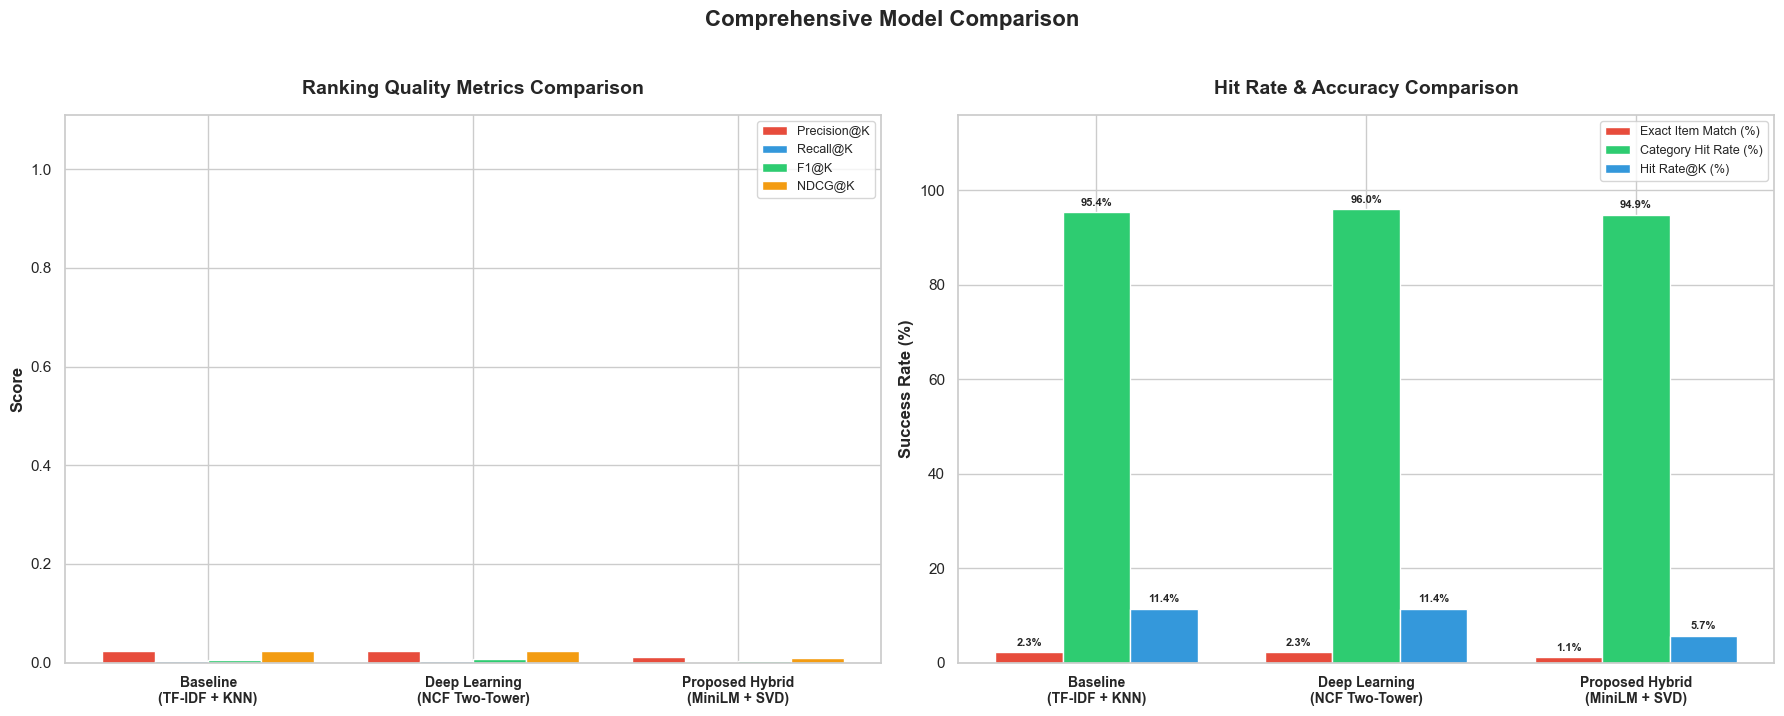

✅ Comparison saved.


In [21]:
# =========================================================
# STEP 10: MASTER COMPARISON CHART & TABLE
# =========================================================
all_results = [base_metrics, ncf_metrics, hybrid_metrics]

# Create clean comparison DataFrame
comparison_data = []
for r in all_results:
    comparison_data.append({k: v for k, v in r.items() if not k.startswith('_')})
comparison_df = pd.DataFrame(comparison_data)
comparison_df.to_csv(os.path.join(results_path, 'master_comparison.csv'), index=False)

print("\n" + "=" * 70)
print("📊 COMPLETE EVALUATION RESULTS")
print("=" * 70)
display(comparison_df.style.highlight_max(axis=0, subset=[c for c in comparison_df.columns if c != 'Model'], 
                                           props='background-color: #d4edda; font-weight: bold'))

# --- Bar Chart: Key Metrics ---
models = ['Baseline\n(TF-IDF + KNN)', 'Deep Learning\n(NCF Two-Tower)', 'Proposed Hybrid\n(MiniLM + SVD)']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Precision-based metrics
ax1 = axes[0]
x = np.arange(len(models))
width = 0.2

bars1 = ax1.bar(x - width*1.5, [r['Precision@K'] for r in all_results], width, label='Precision@K', color='#e74c3c')
bars2 = ax1.bar(x - width*0.5, [r['Recall@K'] for r in all_results], width, label='Recall@K', color='#3498db')
bars3 = ax1.bar(x + width*0.5, [r['F1@K'] for r in all_results], width, label='F1@K', color='#2ecc71')
bars4 = ax1.bar(x + width*1.5, [r['NDCG@K'] for r in all_results], width, label='NDCG@K', color='#f39c12')

ax1.set_ylabel('Score', fontweight='bold', fontsize=12)
ax1.set_title('Ranking Quality Metrics Comparison', fontweight='bold', fontsize=14, pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontweight='bold', fontsize=10)
ax1.legend(fontsize=9)
ax1.set_ylim(0, max([r['Category_Hit_Rate'] for r in all_results]) + 0.15)

# Plot 2: Hit rates
ax2 = axes[1]
width2 = 0.25
bars5 = ax2.bar(x - width2, [r['Exact_Match_Precision']*100 for r in all_results], width2, label='Exact Item Match (%)', color='#e74c3c')
bars6 = ax2.bar(x, [r['Category_Hit_Rate']*100 for r in all_results], width2, label='Category Hit Rate (%)', color='#2ecc71')
bars7 = ax2.bar(x + width2, [r['Hit_Rate@K']*100 for r in all_results], width2, label='Hit Rate@K (%)', color='#3498db')

ax2.set_ylabel('Success Rate (%)', fontweight='bold', fontsize=12)
ax2.set_title('Hit Rate & Accuracy Comparison', fontweight='bold', fontsize=14, pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(models, fontweight='bold', fontsize=10)
ax2.legend(fontsize=9)

ax2.bar_label(bars5, padding=3, fmt='%.1f%%', fontsize=8, fontweight='bold')
ax2.bar_label(bars6, padding=3, fmt='%.1f%%', fontsize=8, fontweight='bold')
ax2.bar_label(bars7, padding=3, fmt='%.1f%%', fontsize=8, fontweight='bold')

max_val = max([r['Category_Hit_Rate']*100 for r in all_results] + [r['Hit_Rate@K']*100 for r in all_results])
ax2.set_ylim(0, max_val + 20)

plt.suptitle('Comprehensive Model Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(plots_path, 'master_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✅ Comparison saved.")

📊 Generating Confusion Matrices for all models...


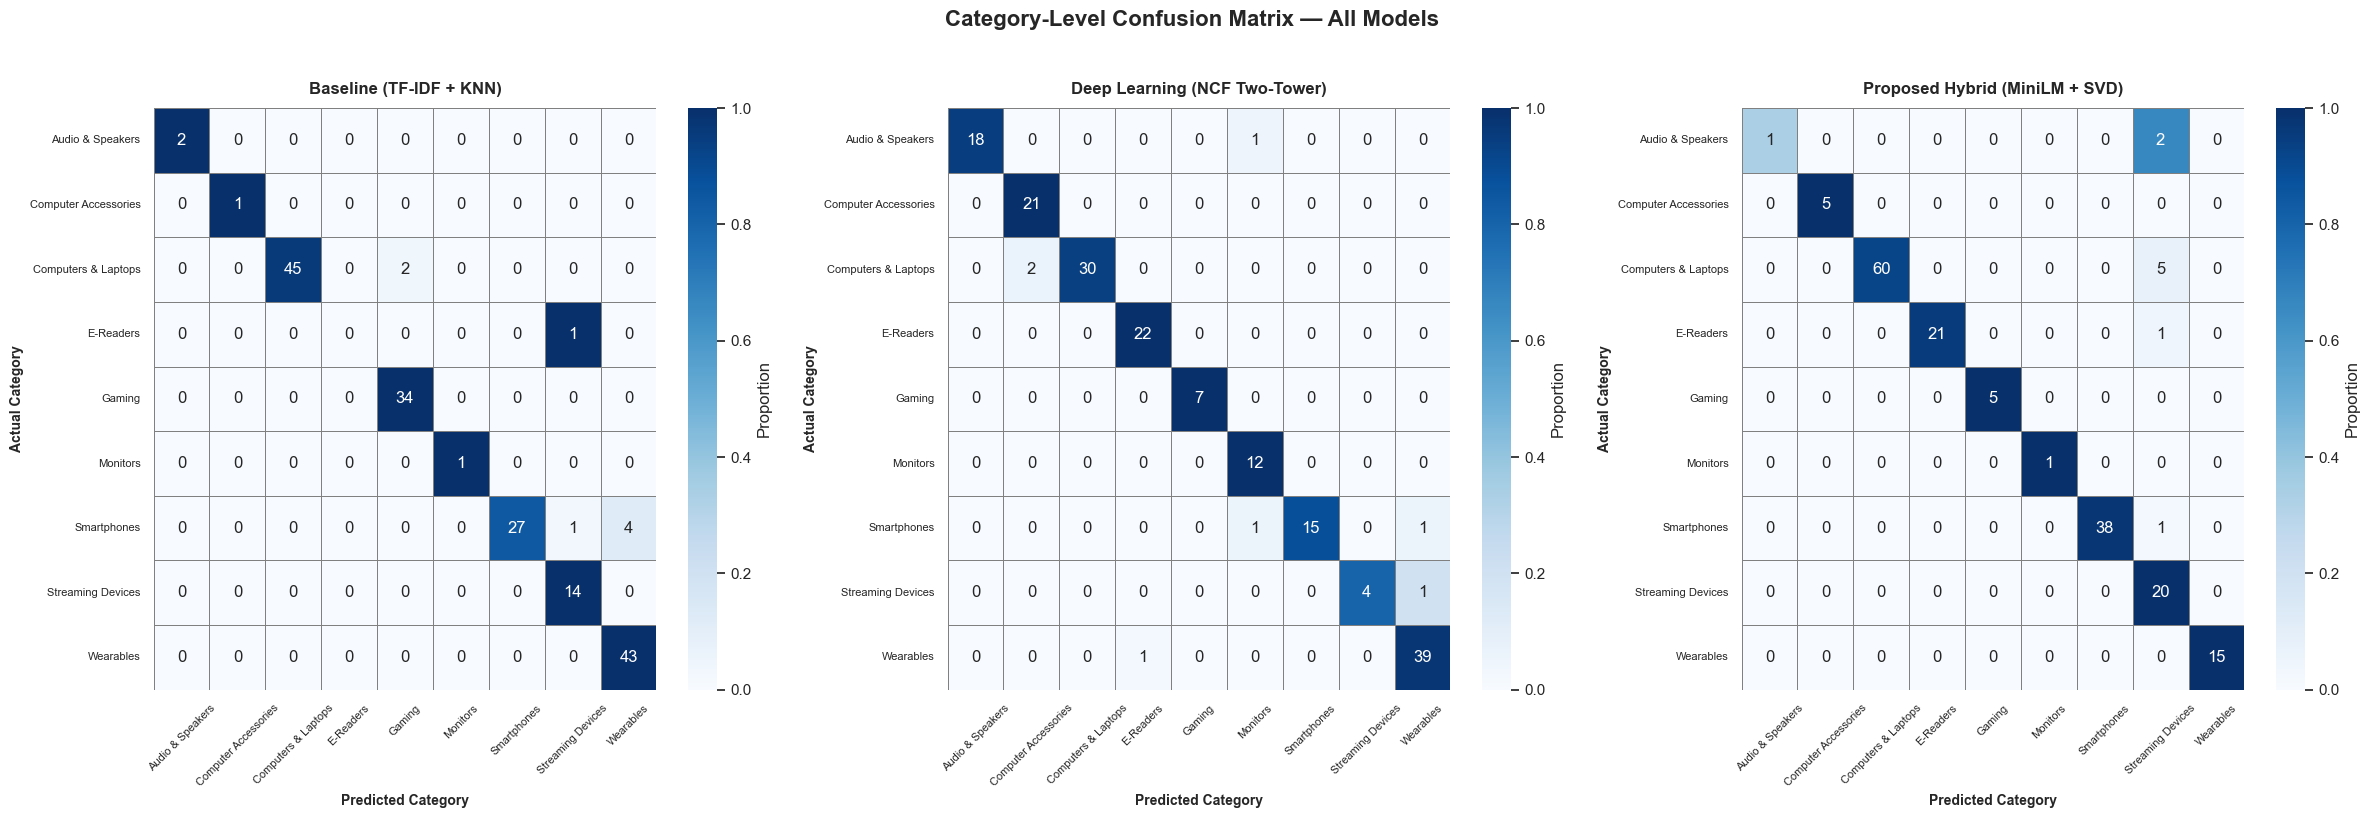

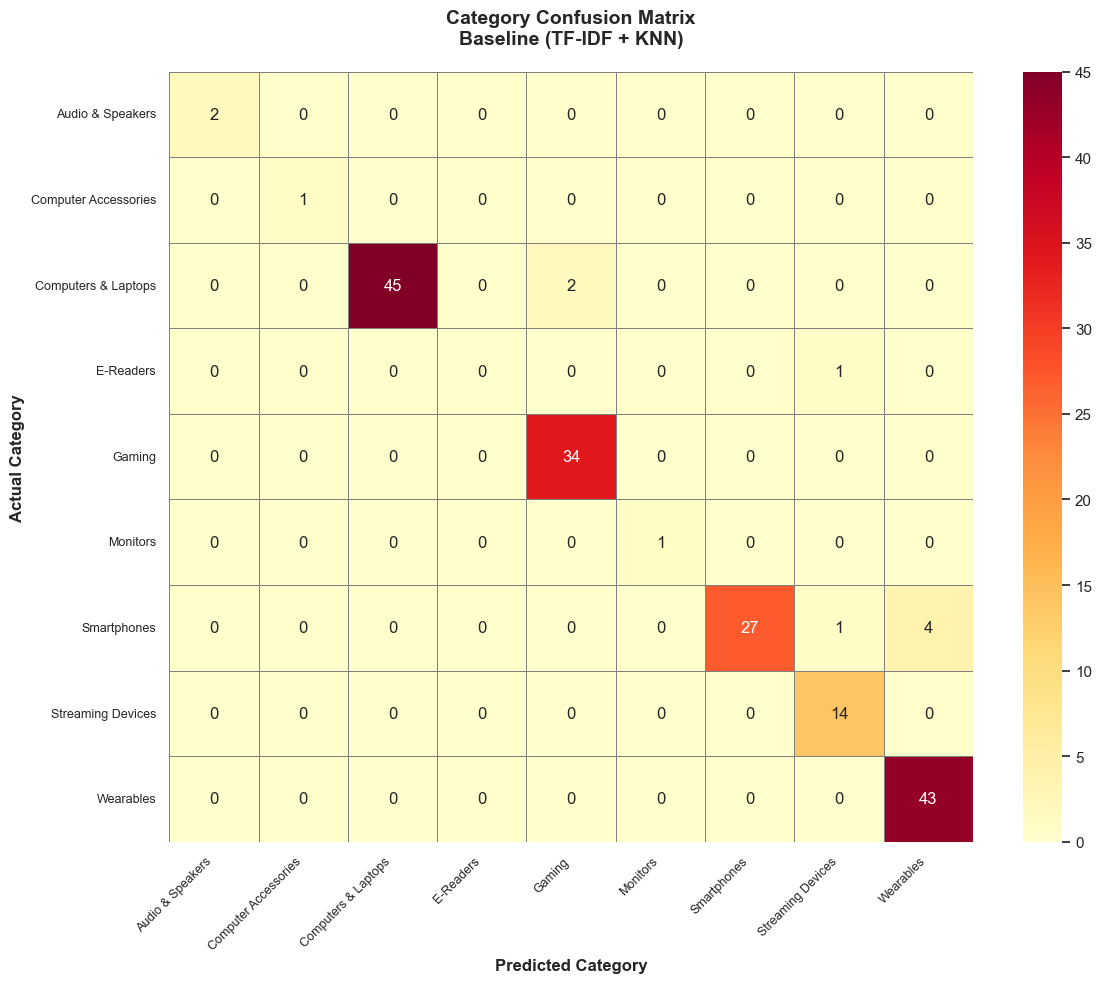

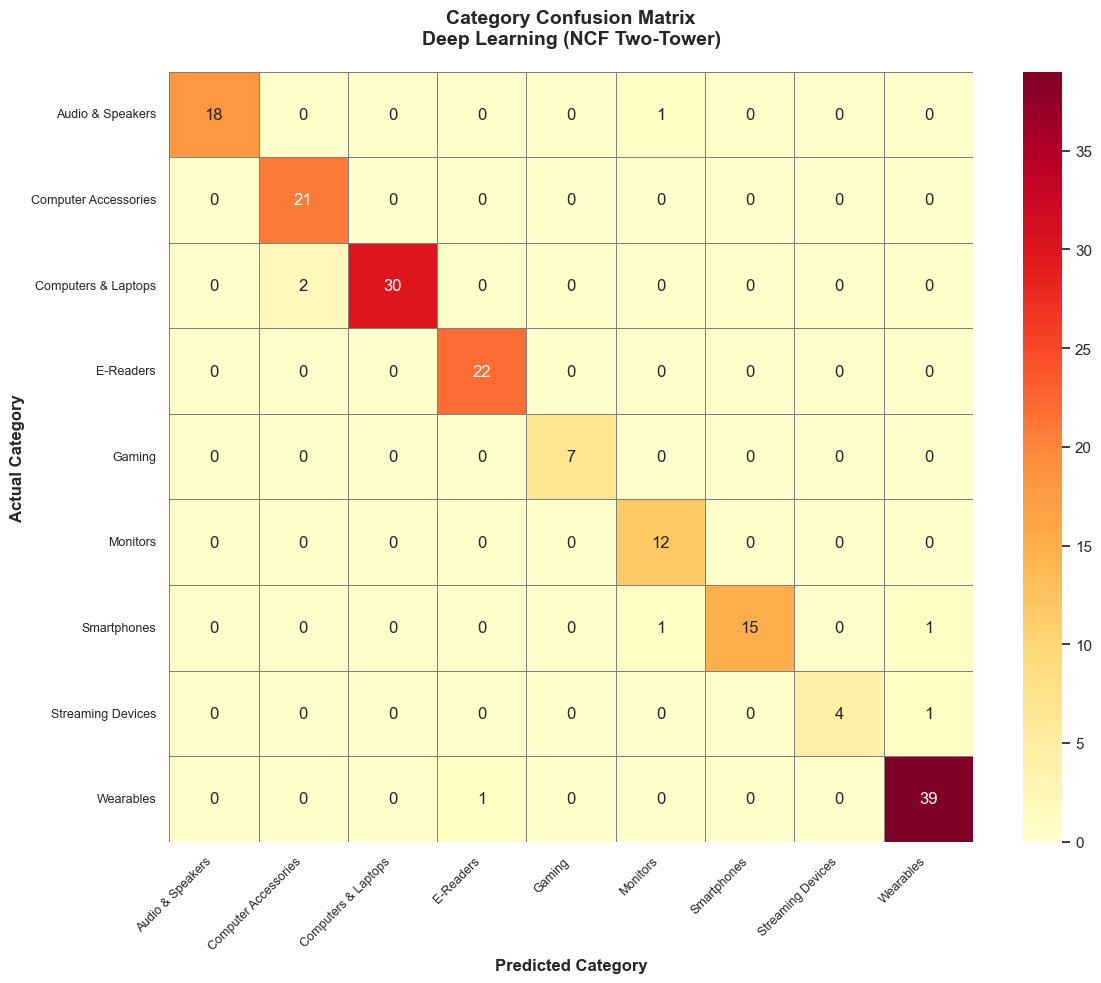

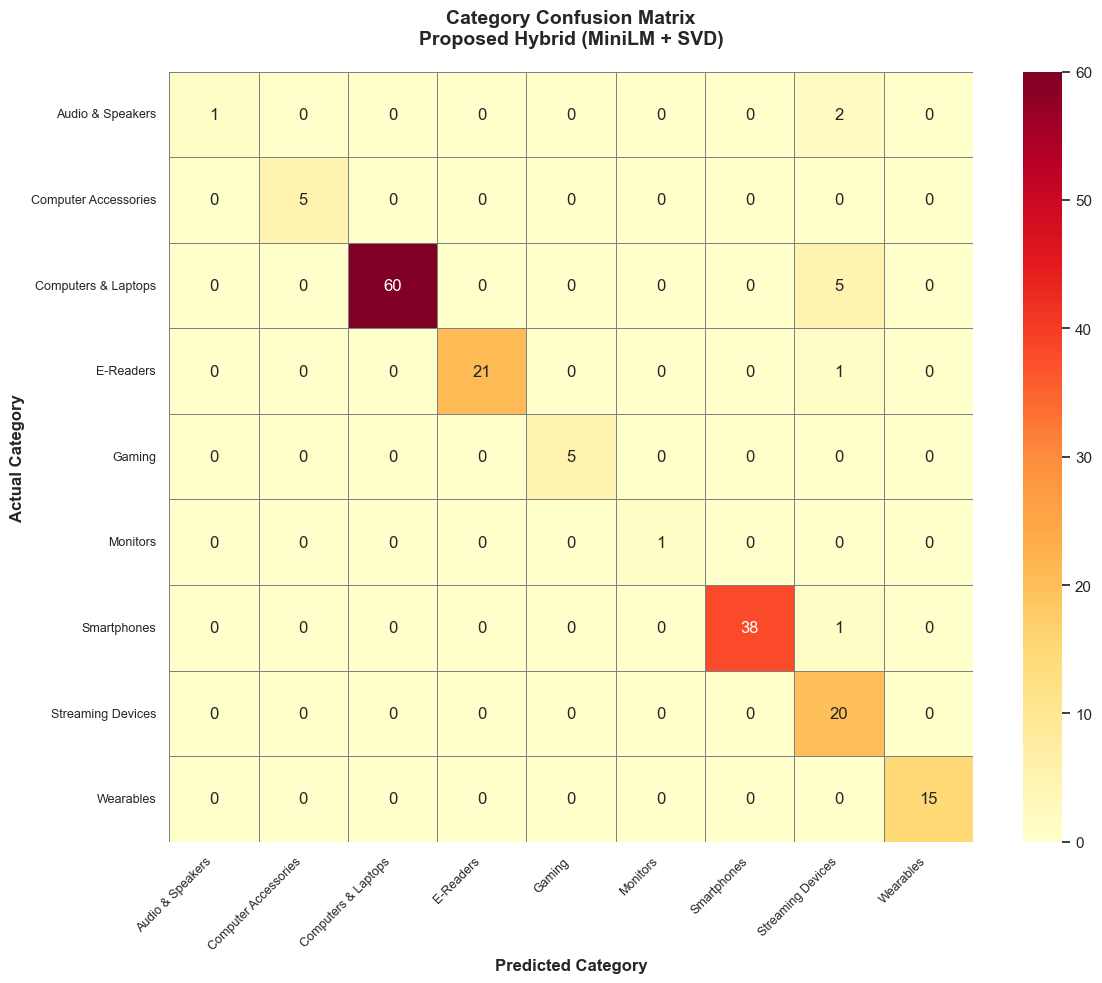

✅ Confusion matrices generated.


In [22]:
# =========================================================
# STEP 11: CATEGORY-LEVEL CONFUSION MATRIX
# =========================================================
print("📊 Generating Confusion Matrices for all models...")

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
model_results_list = [
    ("Baseline (TF-IDF + KNN)", base_metrics),
    ("Deep Learning (NCF Two-Tower)", ncf_metrics),
    ("Proposed Hybrid (MiniLM + SVD)", hybrid_metrics)
]

for idx, (name, result) in enumerate(model_results_list):
    pred_cats = result.get('_pred_categories', [])
    actual_cats = result.get('_actual_categories', [])
    
    if not pred_cats or not actual_cats:
        axes[idx].text(0.5, 0.5, 'No data available', ha='center', va='center', fontsize=14)
        axes[idx].set_title(name)
        continue
    
    all_labels = sorted(list(set(pred_cats + actual_cats)))
    cm = confusion_matrix(actual_cats, pred_cats, labels=all_labels)
    
    # Normalize for better visualization
    cm_normalized = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-10)
    
    sns.heatmap(cm_normalized, annot=cm, fmt='d', cmap='Blues',
                xticklabels=all_labels, yticklabels=all_labels,
                linewidths=0.5, linecolor='gray', ax=axes[idx],
                cbar_kws={'label': 'Proportion'})
    
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold', pad=10)
    axes[idx].set_xlabel('Predicted Category', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Actual Category', fontsize=10, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=45, labelsize=8)
    axes[idx].tick_params(axis='y', rotation=0, labelsize=8)

plt.suptitle('Category-Level Confusion Matrix — All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(plots_path, 'confusion_matrix_all_models.png'), dpi=300, bbox_inches='tight')
plt.show()

# Individual high-res confusion matrices
for name, result in model_results_list:
    pred_cats = result.get('_pred_categories', [])
    actual_cats = result.get('_actual_categories', [])
    
    if not pred_cats or not actual_cats:
        continue
    
    all_labels = sorted(list(set(pred_cats + actual_cats)))
    cm = confusion_matrix(actual_cats, pred_cats, labels=all_labels)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
                xticklabels=all_labels, yticklabels=all_labels,
                linewidths=0.5, linecolor='gray')
    
    plt.title(f'Category Confusion Matrix\n{name}', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Predicted Category', fontsize=12, fontweight='bold')
    plt.ylabel('Actual Category', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '').replace('+', '').lower()
    plt.savefig(os.path.join(plots_path, f'confusion_matrix_{safe_name}.png'), dpi=300, bbox_inches='tight')
    plt.show()

print("✅ Confusion matrices generated.")

📊 Generating ROC Curves...


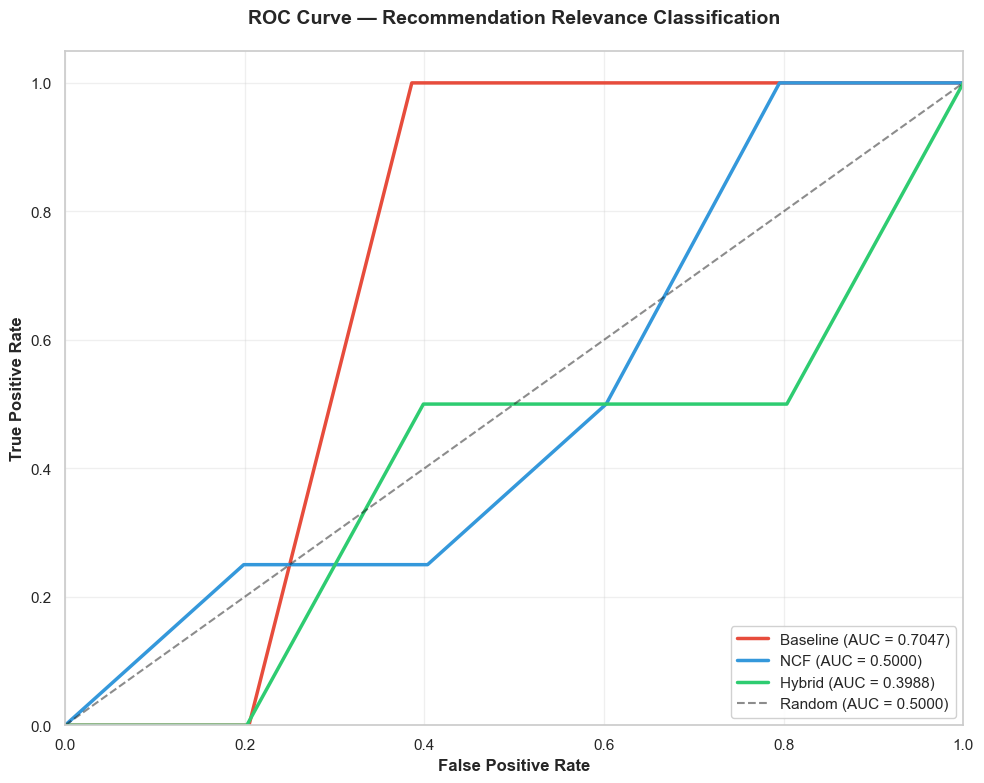


📋 AUC Score Summary:
   Baseline (TF-IDF + KNN): 0.7047
   Deep Learning (NCF Two-Tower): 0.5000
   Proposed Hybrid (MiniLM + SVD): 0.3988
✅ ROC curves generated.


In [23]:
# =========================================================
# STEP 12: ROC CURVE WITH AUC SCORES
# =========================================================
print("📊 Generating ROC Curves...")

plt.figure(figsize=(10, 8))
colors = ['#e74c3c', '#3498db', '#2ecc71']
model_names_short = ['Baseline', 'NCF', 'Hybrid']

auc_scores = {}

for idx, (name, result) in enumerate(model_results_list):
    scores = result.get('_relevance_scores', [])
    labels = result.get('_relevance_labels', [])
    
    if not scores or not labels or sum(labels) == 0:
        print(f"   ⚠️ {name}: No positive samples for ROC curve")
        continue
    
    fpr, tpr, thresholds = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    auc_scores[name] = roc_auc
    
    plt.plot(fpr, tpr, color=colors[idx], linewidth=2.5,
             label=f'{model_names_short[idx]} (AUC = {roc_auc:.4f})')

# Random classifier baseline
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1.5, label='Random (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve — Recommendation Relevance Classification', fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_path, 'roc_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print AUC Summary
print("\n📋 AUC Score Summary:")
for model, score in auc_scores.items():
    print(f"   {model}: {score:.4f}")
print("✅ ROC curves generated.")

In [24]:
# =========================================================
# STEP 13: THE ULTIMATE MODEL COMPARATOR
# =========================================================
def check_all_models(target_user, top_k=TOP_K):
    print("=" * 70)
    print(f"🔍 ANALYZING USER ID: {target_user}")
    print("=" * 70)

    global_max_date = train_df['timestamp'].max()
    user_history = train_df[train_df['userId'] == target_user].sort_values(by='timestamp', ascending=False)

    if user_history.empty:
        user_type, status = "🆕 NEW USER (Cold Start)", "No previous history found."
    else:
        days_since_active = (global_max_date - user_history['timestamp'].max()).total_seconds() / 86400.0
        if days_since_active > 7:
            user_type, status = "🕰️ LONG-TERM USER", f"Last active {days_since_active:.1f} days ago."
        else:
            user_type, status = "⚡ SHORT-TERM USER", f"Recently active ({days_since_active:.1f} days ago)."

    print(f"👤 USER TYPE: {user_type}\n📊 STATUS:    {status}")
    if not user_history.empty:
        print("\n📜 RECENT HISTORY (Last 3):")
        display(user_history[['productId', 'product_name', 'category', 'action_type']].head(3))
    print("-" * 70)

    print("\n🤖 MODEL 1: Baseline (TF-IDF + KNN)")
    try:
        display(get_baseline_recommendations(target_user, top_k)[['productId', 'product_name', 'category']].style.set_properties(**{'background-color': '#f9ebea'}))
    except Exception as e: print(f"⚠️ Error: {e}")

    print("\n🧠 MODEL 2: Deep Learning (NCF Two-Tower)")
    try:
        display(get_ncf_recommendations(target_user, top_k)[['productId', 'product_name', 'category']].style.set_properties(**{'background-color': '#eaf2f8'}))
    except Exception as e: print(f"⚠️ Error: {e}")

    print("\n👑 MODEL 3: Proposed Hybrid Model")
    try:
        display(get_hybrid_recommendations(target_user, top_k)[['productId', 'product_name', 'category']].style.set_properties(**{'background-color': '#e9f7ef', 'font-weight': 'bold'}))
    except Exception as e: print(f"⚠️ Error: {e}")
    print("=" * 70)

# TEST IT OUT:
check_all_models('U015')

🔍 ANALYZING USER ID: U015
👤 USER TYPE: ⚡ SHORT-TERM USER
📊 STATUS:    Recently active (3.0 days ago).

📜 RECENT HISTORY (Last 3):


,productId,product_name,category,action_type
3426,B0B82LCPGM,Stainless Steel Case and Band Compatible with ...,Wearables,cart
3400,B0C5H1WHMR,"Bluetooth Mouse Ergonomic Shape, Silent Click,...",Computer Accessories,view
3413,B0F824TLH3,"Stick-On Mouse Holder for Laptop, Adhesive Sto...",Computer Accessories,view


----------------------------------------------------------------------

🤖 MODEL 1: Baseline (TF-IDF + KNN)


,productId,product_name,category
0,B0FB9567V2,"Compatible Apple Watch Ultra Bands for Men, Wide Soft Nylon Sport Loop, Sturdy Magnetic Buckle for iWatch 49mm (Ultra3/2), 46mm (11/10 Series), 45mm (9/8/7), 44mm (SE/2/SE/6/5/4), 42mm (3/2/1)",Wearables
1,B09V4S6V6K,"Sony PlayStation 5 Digital Edition Console With Accessories, 825GB - White (Renewed)",Gaming
2,B09RTWS8PY,Sony PlayStation 5 Disc Version (Renewed),Gaming
3,B0FQVR59YL,"Portable Charger for Apple Watch, 2500mAh & Digital Display – Magnetic Fast Charging iWatch Charger for Travel & Keychain Use – Works with Apple Watch Series (Black)",Wearables
4,B0C9DQMQDF,"Compatible with Apple Watch Band 38mm 40mm 41mm 42mm 44mm 45mm 46mm 49mm, Rugged Velcro Strap With Three Buckle Loop Tough Nylon Band For iWatch Ultra Series 10/9/8/7/6/5/4/3/2/1/SE",Wearables



🧠 MODEL 2: Deep Learning (NCF Two-Tower)


,productId,product_name,category
0,B0DP3N9CFF,"10ft Prong Power Cord for Sony PS5, PlayStation 5, Xbox One S/X Series X/S",Gaming
1,B0DTHJPY58,kwmobile Cork Case Compatible with Amazon Kindle Paperwhite (2024)/Colorsoft - Book Style Protective e-Reader Flip Cover Folio Case - Pattern Brown/Blue/Red,E-Readers
2,B0CL7Z3RLQ,"Apple Watch Series 8 [GPS + Cellular, 45mm] - Graphite Stainless Steel with Graphite Milanese Loop, One Size (Renewed)",Wearables
3,B0FX3V6K67,"Travel Storage Case Compatible with Logitech MX Master 4/3/3S/2S & MX Anywhere 3S/2S Advanced Wireless Mouse, Universal Protective Mouse Bag for M720 Triathlon / M705 Marathon (Case Only)",Gaming
4,B0DTHK257F,ADP-400GR Internal Power Supply Replacement AC Adapter Power Source Unit for Sony PlayStation 5 PS5 Slim CFI-2000 Series Console Only (NOT Fit for ADP-400DR or ADP-400FR),Gaming



👑 MODEL 3: Proposed Hybrid Model


,productId,product_name,category
0,B0CTD9KC4T,Apple Watch Series 9 (GPS + LTE) 45MM Stainless Steel Case Silver Milanese Loop (Renewed),Wearables
1,B0DM63FVXN,Stainless Steel Integrated Watch Strap，For Apple Watch Band 44mm 45mm，Men Women Metal Bracelet Accessories，For Iwatch Series 9 8 7 6 5 4 SE Watchband,Wearables
2,B0DQYYVNYF,"Apple Watch Series 9 [GPS + Cellular, 45mm] - Silver Stainless Steel Case with Storm Blue Sport Band, M/L (Renewed Premium)",Wearables
3,B0F824TLH3,"Stick-On Mouse Holder for Laptop, Adhesive Storage Pouch Compatible with Logitech Anywhere, Pebble & Pop, Magic Mouse 1 & 2, Black",Computer Accessories
4,B0B82LCPGM,"Stainless Steel Case and Band Compatible with Apple Watch Bands for Men, Metal Rugged Protective Bumper for iWatch Apple Watch Series 9 8 7 45mm Band, Silver",Wearables


In [25]:
# =========================================================
# STEP 14: FINAL SUMMARY & EXPORT
# =========================================================
print("=" * 70)
print("🏁 PIPELINE EXECUTION COMPLETE")
print("=" * 70)

print("\n📊 Final Metrics Summary:")
final_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in all_results])
display(final_df.round(4))

print(f"\n📁 All plots saved to: {plots_path}")
print(f"📁 All results saved to: {results_path}")

print("\n📈 Generated Visualizations:")
print("  1. EDA Overview (action funnel, trends, brands, prices)")
print("  2. Dynamic Weights Curve (α/β decay)")
print("  3. NCF Training & Validation Loss Curve")
print("  4. NCF Training & Validation Accuracy Curve")
print("  5. Master Comparison Chart (all metrics)")
print("  6. Category Confusion Matrix (per model)")
print("  7. ROC Curve with AUC (all models)")
print("  8. Model Comparator Output")

# Save final summary
final_df.to_csv(os.path.join(results_path, 'final_summary.csv'), index=False)
print("\n✅ All outputs saved successfully!")

🏁 PIPELINE EXECUTION COMPLETE

📊 Final Metrics Summary:


,Model,Precision@K,Recall@K,F1@K,NDCG@K,MAP@K,Hit_Rate@K,Exact_Match_Precision,Category_Hit_Rate,MRR
0,Baseline (TF-IDF + KNN),0.0229,0.0031,0.0054,0.0245,0.0114,0.1143,0.0229,0.9543,0.0571
1,Deep Learning (NCF Two-Tower),0.0229,0.0037,0.0063,0.0229,0.0105,0.1143,0.0229,0.9600,0.0524
2,Proposed Hybrid (MiniLM + SVD),0.0114,0.0017,0.0030,0.0099,0.0040,0.0571,0.0114,0.9486,0.0200



📁 All plots saved to: ./results/evaluation_plots/
📁 All results saved to: ./results/evaluation_results/

📈 Generated Visualizations:
  1. EDA Overview (action funnel, trends, brands, prices)
  2. Dynamic Weights Curve (α/β decay)
  3. NCF Training & Validation Loss Curve
  4. NCF Training & Validation Accuracy Curve
  5. Master Comparison Chart (all metrics)
  6. Category Confusion Matrix (per model)
  7. ROC Curve with AUC (all models)
  8. Model Comparator Output

✅ All outputs saved successfully!
